In [1]:
# Cell 1 — Load trained model
"""
03_inference.ipynb
==================
Interactive predictions with a trained TGNN-Solv model.
"""

import sys
sys.path.insert(0, "../src")

import torch
from tgnn_solv.inference import (
    load_model,
    predict_solubility,
    temperature_scan,
    interpret_prediction,
)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
model, cfg = load_model("../checkpoints/tgnn_solv_trained.pt", DEVICE)
print(f"Model loaded, device: {DEVICE}")

Model loaded from ../checkpoints/tgnn_solv_trained.pt
  test_mae: 1.906586766242981
  test_rmse: 2.665729284286499
  test_r2: 0.008077919483184814
  n_train: 104625
  n_test: 7787
Model loaded, device: mps


In [2]:
# Cell 2 — Single prediction with full report
result = predict_solubility(
    model,
    solute_smiles="CC(=O)Nc1ccc(O)cc1",   # paracetamol
    solvent_smiles="CCO",                   # ethanol
    T=298.15,
)
print(interpret_prediction(result))

Solubility Prediction Report
Solute:  CC(=O)Nc1ccc(O)cc1
Solvent: CCO
T = 298.1 K (25.0 °C)

PREDICTED SOLUBILITY:
  x₂ = 0.04849 (mole fraction)
  ln(x₂) = -3.026
  → Moderate solubility (1–10 mol%)

DECOMPOSITION:
  ln(x₂) = -Φ - ln(γ₂) + correction
  = -2.800 + -0.226 + 0.000
  Crystal term (-Φ): -2.800 (93% of total)
  Non-ideal term (-ln γ₂): -0.226 (7%)

CRYSTAL PROPERTIES (solute):
  T_m = 442.0 K (168.9 °C)
  ΔH_fus = 26363 J/mol
  ΔCp_fus = 61.9 J/(mol·K)
  ΔS_fus = 59.6 J/(mol·K) (OK; Walden ≈ 56.5)

ACTIVITY COEFFICIENT:
  γ₂ = 1.254
  → Near-ideal to weak positive deviation

NRTL PARAMETERS:
  Δg₁₂ = 144 J/mol
  Δg₂₁ = 501 J/mol
  α₁₂ = 0.292

HANSEN PARAMETERS:
  Solute:  δd=18.4, δp=10.2, δh=14.0
  Solvent: δd=15.4, δp=9.0, δh=13.5
  Ra = 6.2 MPa^½
  → Good match ('like dissolves like')


In [3]:
# Cell 3 — Compare multiple solvents
solvents = {
    "Water": "O",
    "Ethanol": "CCO",
    "Methanol": "CO",
    "Acetone": "CC(=O)C",
    "Hexane": "CCCCCC",
    "Toluene": "Cc1ccccc1",
    "DMSO": "CS(=O)C",
    "Chloroform": "ClC(Cl)Cl",
}

solute = "CC(=O)Nc1ccc(O)cc1"  # paracetamol
print(f"{'Solvent':15s} {'x₂':>10s} {'ln(x₂)':>8s} {'γ₂':>8s} {'Ra':>6s}")
print("-" * 50)

for name, smi in solvents.items():
    r = predict_solubility(model, solute, smi, T=298.15)
    print(f"{name:15s} {r['x2']:10.5f} {r['ln_x2']:8.3f} "
          f"{r['gamma_2']:8.2f} {r['Ra']:6.1f}")

Toluene            0.00000  -14.839 244553451646082.03   17.6
DMSO               0.19886   -1.615     0.31    7.2
Chloroform         0.00228   -6.082    26.62   15.9


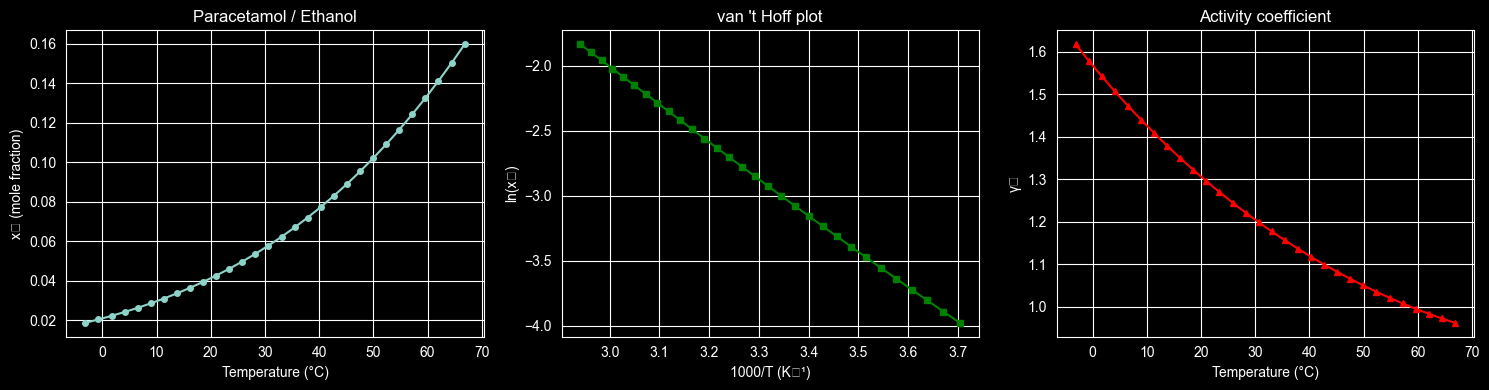

In [5]:
# Cell 4 — Temperature scan with plot
import matplotlib.pyplot as plt

scan = temperature_scan(
    model,
    solute_smiles="CC(=O)Nc1ccc(O)cc1",
    solvent_smiles="CCO",
    T_min=270, T_max=340, n_points=30,
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Solubility vs T
axes[0].plot(scan["T"] - 273.15, scan["x2"], "o-", ms=4)
axes[0].set_xlabel("Temperature (°C)")
axes[0].set_ylabel("x₂ (mole fraction)")
axes[0].set_title("Paracetamol / Ethanol")

# ln(x2) vs 1/T (van 't Hoff style)
axes[1].plot(1000 / scan["T"], scan["ln_x2"], "s-", ms=4, color="green")
axes[1].set_xlabel("1000/T (K⁻¹)")
axes[1].set_ylabel("ln(x₂)")
axes[1].set_title("van 't Hoff plot")

# γ₂ vs T
axes[2].plot(scan["T"] - 273.15, scan["gamma_2"], "^-", ms=4, color="red")
axes[2].set_xlabel("Temperature (°C)")
axes[2].set_ylabel("γ₂")
axes[2].set_title("Activity coefficient")

plt.tight_layout()
plt.show()

# Monotonicity check
#diffs = scan["ln_x2"].diff().dropna()
#print(f"Monotonically increasing: {(diffs >= -0.01).all()}")

In [6]:
# Cell 5 — Batch prediction
import pandas as pd

systems = [
    ("CC(=O)Nc1ccc(O)cc1", "O", 298.15),       # paracetamol / water
    ("CC(=O)Nc1ccc(O)cc1", "CCO", 298.15),      # paracetamol / ethanol
    ("c1ccc2ccccc2c1", "c1ccccc1", 298.15),      # naphthalene / benzene
    ("c1ccc2ccccc2c1", "O", 298.15),             # naphthalene / water
    ("OC(=O)c1ccccc1", "CCO", 298.15),           # benzoic acid / ethanol
    ("OC(=O)c1ccccc1", "O", 298.15),             # benzoic acid / water
    ("CC(=O)Oc1ccccc1C(=O)O", "CCO", 298.15),   # aspirin / ethanol
    ("CC(=O)Oc1ccccc1C(=O)O", "O", 298.15),     # aspirin / water
]

results = []
for sol, slv, T in systems:
    r = predict_solubility(model, sol, slv, T)
    results.append(r)

df = pd.DataFrame(results)
display_cols = ["solute", "solvent", "x2", "ln_x2", "gamma_2",
                "T_m", "dH_fus", "Ra", "correction"]
print(df[display_cols].to_string(index=False, float_format="{:.4f}".format))

               solute  solvent     x2   ln_x2  gamma_2      T_m     dH_fus      Ra  correction
   CC(=O)Nc1ccc(O)cc1        O 0.0437 -3.1298   1.3901 442.0241 26362.9062  6.2442      0.0000
   CC(=O)Nc1ccc(O)cc1      CCO 0.0485 -3.0264   1.2535 442.0241 26362.9023  6.2408      0.0000
       c1ccc2ccccc2c1 c1ccccc1 0.2395 -1.4294   0.9797 362.1821 19057.7207  8.4716     -0.0000
       c1ccc2ccccc2c1        O 0.0764 -2.5718   3.0717 362.1821 19057.7188 10.4155      0.0000
       OC(=O)c1ccccc1      CCO 0.1626 -1.8164   1.1088 393.6638 18021.7344  7.0410      0.0000
       OC(=O)c1ccccc1        O 0.1447 -1.9330   1.2458 393.6638 18021.7305  5.0642      0.0000
CC(=O)Oc1ccccc1C(=O)O      CCO 0.0561 -2.8811   1.2724 404.5907 29786.3027  5.9133      0.0000
CC(=O)Oc1ccccc1C(=O)O        O 0.0478 -3.0401   1.4917 404.5908 29786.2988  3.8685     -0.0000


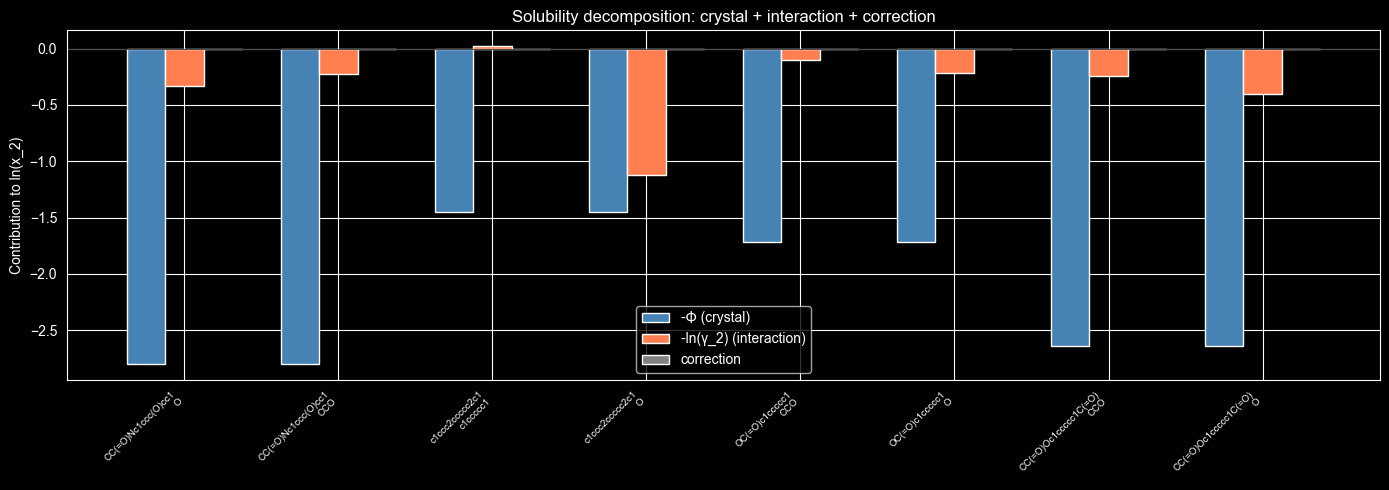

In [7]:
# Cell 6 — Interpretability: decomposition chart
import matplotlib.pyplot as plt
import numpy as np

# Use results from Cell 5
names = [f"{r['solute'][:20]}\n{r['solvent'][:10]}" for r in results]
phi = [-r["Phi"] for r in results]
lng = [-r["ln_gamma_2"] for r in results]
corr = [r["correction"] for r in results]

x_pos = np.arange(len(results))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x_pos - width, phi, width, label="-Φ (crystal)", color="steelblue")
ax.bar(x_pos, lng, width, label="-ln(γ_2) (interaction)", color="coral")
ax.bar(x_pos + width, corr, width, label="correction", color="gray")

ax.set_xticks(x_pos)
ax.set_xticklabels(names, fontsize=7, rotation=45, ha="right")
ax.set_ylabel("Contribution to ln(x_2)")
ax.set_title("Solubility decomposition: crystal + interaction + correction")
ax.legend()
ax.axhline(0, color="black", lw=0.5)
plt.tight_layout()
plt.show()